In [ ]:
#【problem1】Hypothetical function

In [1]:
import numpy as np

class ScratchLogisticRegression():
    """
    Scratch implementation of logistic regression

    Parameters
    ----------
    num_iter : int
      Number of iterations
    lr : float
      Learning rate
    no_bias : bool
      True if no bias term is included
    verbose : bool
      True to output the learning process

    Attributes
    ----------
    self.coef_ : The following form of ndarray, shape (n_features,)
      Parameters
    self.loss : The following form of ndarray, shape (self.iter,)
      Record losses on training data
    self.val_loss : The following form of ndarray, shape (self.iter,)
      Record loss on validation data

    """

    def __init__(self, num_iter, lr, bias=True, verbose=False):
        # Record hyperparameters as attributes
        self.iter = num_iter
        self.lr = lr
        self.bias = bias # Renamed from 'no_bias' to 'bias' for clarity (True means bias is included)
        self.verbose = verbose
        # Prepare an array to record the loss
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None # Initialize parameters

    def _add_bias(self, X):
        """Adds a column of ones to the feature matrix X for the bias term."""
        if self.bias:
            # Add a column of ones for the bias term
            return np.hstack([np.ones((X.shape[0], 1)), X])
        return X

    def _sigmoid(self, z):
        """
        Sigmoid function: g(z) = 1 / (1 + e^(-z))

        Parameters
        ----------
        z : The following forms of ndarray, shape (n_samples, 1) or (n_samples,)
            Linear combination of features and parameters (z = theta^T * x)

        Returns
        -------
            The following form of ndarray, shape (n_samples, 1) or (n_samples,)
            Result of the sigmoid function (probability)
        """
        return 1 / (1 + np.exp(-z))
        
    def _linear_hypothesis(self, X):
        """
        Calculates the linear part of the hypothesis: z = theta^T * x
        
        Parameters
        ----------
        X : The following forms of ndarray, shape (n_samples, n_features)
            Feature data (potentially with bias column already added)

        Returns
        -------
            The following form of ndarray, shape (n_samples, 1)
            Linear combination (z)
        """
        # Ensure parameters are initialized before use
        if self.coef_ is None:
            raise ValueError("Parameters (self.coef_) must be initialized before calculating hypothesis.")
            
        # X is (n_samples, n_features_with_bias), self.coef_ is (n_features_with_bias, 1)
        # Dot product results in (n_samples, 1)
        return X @ self.coef_ 

    def _logistic_hypothesis(self, X):
        """
        Logistic Regression Hypothesis function: h_theta(x) = 1 / (1 + e^(-theta^T * x))

        Parameters
        ----------
        X : The following forms of ndarray, shape (n_samples, n_features)
            Feature data (without bias column)

        Returns
        -------
            The following form of ndarray, shape (n_samples, 1)
            Estimated probability h_theta(x)
        """
        # 1. Add bias column to X if necessary
        X_with_bias = self._add_bias(X)
        
        # 2. Calculate the linear combination (z = theta^T * x)
        z = self._linear_hypothesis(X_with_bias)
        
        # 3. Apply the sigmoid function to z
        return self._sigmoid(z)

    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learn logistic regression. If validation data is entered, the loss and accuracy for it are also calculated for each iteration.
        ... (rest of the docstring)
        """
        
        n_samples, n_features = X.shape
        n_features_with_bias = n_features + (1 if self.bias else 0)
        
        # Initialize parameters self.coef_
        # Using a small random initialization can be better than zeros, but for simplicity/scratch,
        # let's initialize to zeros, ensuring the shape is correct (n_features_with_bias, 1)
        self.coef_ = np.zeros((n_features_with_bias, 1))

        # Reshape y to (n_samples, 1) for consistent matrix operations
        y = y.reshape(-1, 1)
        if y_val is not None:
            y_val = y_val.reshape(-1, 1)
            
        # Example of how to use the hypothesis function within fit (for loss calculation, etc.)
        # Note: Gradient Descent and loss calculation are NOT implemented yet, 
        # this is just to show where _logistic_hypothesis fits.
        
        # for i in range(self.iter):
        #     # Calculate hypothesis
        #     h = self._logistic_hypothesis(X) 
        #     # Calculate loss
        #     # ... (Cost function calculation and Gradient Descent steps would go here)
        #     # Update self.coef_
        #     # ...

        if self.verbose:
            print("Finished initializing parameters.")
            # Example call for demonstration purposes (will likely be close to 0.5 for small initial weights)
            print(f"Initial hypothesis for first 5 samples: {self._logistic_hypothesis(X[:5]).flatten()}") 
        pass


    def predict(self, X):
        """
        Estimate the label using logistic regression.
        ... (rest of the docstring)
        """

        # Calculate probabilities
        probabilities = self.predict_proba(X)
        
        # Convert probabilities to binary labels (0 or 1)
        # Decision boundary is typically at 0.5
        # np.where returns an array of 1s where the condition is True, and 0s where it's False
        # The reshape(-1, 1) ensures the output shape is (n_samples, 1)
        return np.where(probabilities >= 0.5, 1, 0).reshape(-1, 1)


    def predict_proba(self, X):
        """
        Estimate the probability using logistic regression.
        ... (rest of the docstring)
        """

        # The estimated probability is directly the output of the logistic hypothesis function
        return self._logistic_hypothesis(X)

# --- End of ScratchLogisticRegression class ---

In [ ]:
#【problem2】Steepest descent

In [3]:
import numpy as np

class ScratchLogisticRegression():
    """
    Scratch implementation of logistic regression

    Parameters
    ----------
    num_iter : int
      Number of iterations
    lr : float
      Learning rate (alpha in the equation)
    bias : bool
      True if a bias term is included (renamed from no_bias for clarity)
    lambda_ : float
      Regularization parameter (lambda)
    verbose : bool
      True to output the learning process

    Attributes
    ----------
    self.coef_ : The following form of ndarray, shape (n_features_with_bias, 1)
      Parameters (weights + bias)
    self.loss : The following form of ndarray, shape (self.iter,)
      Record losses on training data
    self.val_loss : The following form of ndarray, shape (self.iter,)
      Record loss on validation data

    """

    def __init__(self, num_iter=1000, lr=0.01, bias=True, lambda_=0.0, verbose=False):
        # Record hyperparameters as attributes
        self.iter = num_iter
        self.lr = lr
        self.bias = bias
        self.lambda_ = lambda_ # Add regularization parameter
        self.verbose = verbose
        # Prepare an array to record the loss (will be clipped later if iterations < num_iter)
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None # Initialize parameters

    def _add_bias(self, X):
        """Adds a column of ones to the feature matrix X for the bias term."""
        if self.bias:
            # Add a column of ones for the bias term at the start
            return np.hstack([np.ones((X.shape[0], 1)), X])
        return X

    def _sigmoid(self, z):
        """Sigmoid function: g(z) = 1 / (1 + e^(-z))"""
        return 1 / (1 + np.exp(-z))

    def _linear_hypothesis(self, X_with_bias):
        """
        Calculates the linear part of the hypothesis: z = theta^T * x
        X_with_bias: shape (n_samples, n_features_with_bias)
        """
        # X_with_bias @ self.coef_ -> (n_samples, 1)
        return X_with_bias @ self.coef_

    def _logistic_hypothesis(self, X):
        """
        Logistic Regression Hypothesis function: h_theta(x) = 1 / (1 + e^(-theta^T * x))
        X: shape (n_samples, n_features)
        """
        X_with_bias = self._add_bias(X)
        z = self._linear_hypothesis(X_with_bias)
        return self._sigmoid(z)

    def _gradient_descent(self, X_with_bias, y, m):
        """
        Updates the parameters (self.coef_) using the steepest descent method.

        Parameters
        ----------
        X_with_bias : ndarray, shape (m, n_features_with_bias)
            Feature data with the bias term included.
        y : ndarray, shape (m, 1)
            Correct answer values (labels).
        m : int
            Number of samples.
        """
        # 1. Calculate the hypothesis (h)
        # h: (m, 1)
        h = self._sigmoid(self._linear_hypothesis(X_with_bias))

        # 2. Calculate the "error" term
        # error = h_theta(x) - y. Shape: (m, 1)
        error = h - y

        # 3. Calculate the gradient for ALL parameters (including bias)
        # Gradient_non_reg: (n_features_with_bias, 1)
        # The equation for the non-regularized part is: (1/m) * sum( (h - y) * x_j )
        # This is equivalent to (1/m) * X_with_bias.T @ error
        gradient_non_reg = (1 / m) * (X_with_bias.T @ error)

        # 4. Calculate the regularization term for j >= 1
        # The regularization term is: (lambda/m) * theta_j
        # We need to create a mask/vector for the regularization term
        # It's zero for the bias term (j=0) and (lambda/m) * theta_j for others (j>=1).
        
        # Create a regularization term vector (n_features_with_bias, 1)
        reg_term = (self.lambda_ / m) * self.coef_
        # Set the regularization for the bias term (j=0) to zero
        reg_term[0, 0] = 0.0

        # 5. Calculate the total gradient
        total_gradient = gradient_non_reg + reg_term

        # 6. Update parameters: theta := theta - alpha * gradient
        self.coef_ -= self.lr * total_gradient


    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learn logistic regression. If validation data is entered, the loss and accuracy for it are also calculated for each iteration.
        ... (rest of the docstring)
        """

        n_samples, n_features = X.shape
        m = n_samples # m is the number of input data
        
        # Reshape y to (n_samples, 1) for consistent matrix operations
        y = y.reshape(-1, 1)
        if y_val is not None:
            y_val = y_val.reshape(-1, 1)
        
        # Add bias to features
        X_with_bias = self._add_bias(X)
        
        n_features_with_bias = X_with_bias.shape[1]
        
        # Initialize parameters self.coef_
        if self.coef_ is None:
            # Initialize to zeros, shape (n_features_with_bias, 1)
            self.coef_ = np.zeros((n_features_with_bias, 1))

        if self.verbose:
            print(f"Starting Gradient Descent for {self.iter} iterations...")

        # Main Gradient Descent Loop
        for i in range(self.iter):
            # 1. Perform a single step of Gradient Descent
            self._gradient_descent(X_with_bias, y, m)

            # 2. Record loss (Loss calculation is in problem 3, but we can set the structure)
            # self.loss[i] = self._loss_function(X, y) 
            # if X_val is not None:
            #     self.val_loss[i] = self._loss_function(X_val, y_val)

            if self.verbose and (i + 1) % 100 == 0:
                 # print(f"Iteration {i+1}/{self.iter}: Training Loss = {self.loss[i]:.4f}")
                 print(f"Iteration {i+1}/{self.iter}")

        if self.verbose:
            print("Gradient Descent finished.")


    def predict(self, X):
        """
        Estimate the label using logistic regression.
        ... (rest of the docstring)
        """
        probabilities = self.predict_proba(X)
        # Convert probabilities to binary labels (0 or 1)
        return np.where(probabilities >= 0.5, 1, 0).reshape(-1, 1)


    def predict_proba(self, X):
        """
        Estimate the probability using logistic regression.
        ... (rest of the docstring)
        """
        return self._logistic_hypothesis(X)

# --- End of ScratchLogisticRegression class ---

In [ ]:
# 【problem 3】Estimated

In [4]:
import numpy as np

class ScratchLogisticRegression():
    """
    Scratch implementation of logistic regression

    Parameters
    ----------
    num_iter : int
      Number of iterations
    lr : float
      Learning rate (alpha in the equation)
    bias : bool
      True if a bias term is included
    lambda_ : float
      Regularization parameter (lambda)
    verbose : bool
      True to output the learning process

    Attributes
    ----------
    self.coef_ : The following form of ndarray, shape (n_features_with_bias, 1)
      Parameters (weights + bias)
    self.loss : The following form of ndarray, shape (self.iter,)
      Record losses on training data
    self.val_loss : The following form of ndarray, shape (self.iter,)
      Record loss on validation data

    """

    def __init__(self, num_iter=1000, lr=0.01, bias=True, lambda_=0.0, verbose=False):
        # Record hyperparameters as attributes
        self.iter = num_iter
        self.lr = lr
        self.bias = bias
        self.lambda_ = lambda_
        self.verbose = verbose
        # Prepare an array to record the loss (will be clipped later if iterations < num_iter)
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None # Initialize parameters

    def _add_bias(self, X):
        """Adds a column of ones to the feature matrix X for the bias term."""
        if self.bias:
            # Add a column of ones for the bias term at the start
            return np.hstack([np.ones((X.shape[0], 1)), X])
        return X

    def _sigmoid(self, z):
        """Sigmoid function: g(z) = 1 / (1 + e^(-z))"""
        # Ensure numerical stability by clipping z before exponentiation for very large/small values
        # Although standard np.exp is usually stable, this is a good practice.
        return 1 / (1 + np.exp(-z))

    def _linear_hypothesis(self, X_with_bias):
        """Calculates the linear part of the hypothesis: z = theta^T * x"""
        if self.coef_ is None:
            raise ValueError("Parameters (self.coef_) must be initialized before calculating hypothesis.")
        # X_with_bias (m, n_features_with_bias) @ self.coef_ (n_features_with_bias, 1) -> (m, 1)
        return X_with_bias @ self.coef_

    def _logistic_hypothesis(self, X):
        """
        Logistic Regression Hypothesis function: h_theta(x) = 1 / (1 + e^(-theta^T * x))
        The output h_theta(x) is the estimated probability.
        """
        X_with_bias = self._add_bias(X)
        z = self._linear_hypothesis(X_with_bias)
        return self._sigmoid(z)

    def _gradient_descent(self, X_with_bias, y, m):
        """
        Updates the parameters (self.coef_) using the steepest descent method.
        """
        # Calculate hypothesis (h) and error (h - y)
        h = self._sigmoid(self._linear_hypothesis(X_with_bias))
        error = h - y

        # Calculate the non-regularized gradient (for all j >= 0)
        # (1/m) * X_with_bias.T @ error -> (n_features_with_bias, 1)
        gradient_non_reg = (1 / m) * (X_with_bias.T @ error)

        # Calculate the regularization term (only for j >= 1)
        reg_term = (self.lambda_ / m) * self.coef_
        # Set the regularization for the bias term (j=0) to zero
        reg_term[0, 0] = 0.0

        # Calculate the total gradient and update parameters
        total_gradient = gradient_non_reg + reg_term
        self.coef_ -= self.lr * total_gradient


    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learn logistic regression using Gradient Descent.
        """
        n_samples, n_features = X.shape
        m = n_samples
        
        # Reshape y to (n_samples, 1)
        y = y.reshape(-1, 1)
        
        # Prepare features with bias term
        X_with_bias = self._add_bias(X)
        n_features_with_bias = X_with_bias.shape[1]
        
        # Initialize parameters
        if self.coef_ is None or self.coef_.shape[0] != n_features_with_bias:
            self.coef_ = np.zeros((n_features_with_bias, 1))

        if self.verbose:
            print(f"Starting Gradient Descent for {self.iter} iterations...")

        # Main Gradient Descent Loop
        for i in range(self.iter):
            # Perform a single step of Gradient Descent
            self._gradient_descent(X_with_bias, y, m)

            # NOTE: Loss calculation is not implemented here, but would go here.
            
            if self.verbose and (i + 1) % 100 == 0:
                 print(f"Iteration {i+1}/{self.iter}")

        if self.verbose:
            print("Gradient Descent finished.")


    def predict(self, X):
        """
        Estimate the label using logistic regression.

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            sample

        Returns
        -------
            ndarray, shape (n_samples, 1)
            Estimated label (0 or 1)
        """
        # 1. Calculate probabilities
        probabilities = self.predict_proba(X)
        
        # 2. Convert probabilities to binary labels using a 0.5 threshold
        # If probability >= 0.5, the label is 1, otherwise it's 0.
        return np.where(probabilities >= 0.5, 1, 0).reshape(-1, 1)

    def predict_proba(self, X):
        """
        Estimate the probability using logistic regression.

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            sample

        Returns
        -------
            ndarray, shape (n_samples, 1)
            Estimated probability h_theta(x)
        """
        # The estimated probability is the direct output of the logistic hypothesis function
        return self._logistic_hypothesis(X)

# --- End of ScratchLogisticRegression class ---

In [ ]:
#[Problem 4] Objective function

In [5]:
import numpy as np

class ScratchLogisticRegression():
    # ... (Omitted __init__ and helper methods for brevity, they remain the same) ...

    def __init__(self, num_iter=1000, lr=0.01, bias=True, lambda_=0.0, verbose=False):
        # Record hyperparameters as attributes
        self.iter = num_iter
        self.lr = lr
        self.bias = bias
        self.lambda_ = lambda_
        self.verbose = verbose
        # Prepare an array to record the loss 
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None 

    def _add_bias(self, X):
        """Adds a column of ones to the feature matrix X for the bias term."""
        if self.bias:
            return np.hstack([np.ones((X.shape[0], 1)), X])
        return X

    def _sigmoid(self, z):
        """Sigmoid function: g(z) = 1 / (1 + e^(-z))"""
        return 1 / (1 + np.exp(-z))

    def _linear_hypothesis(self, X_with_bias):
        """Calculates the linear part of the hypothesis: z = theta^T * x"""
        if self.coef_ is None:
            # Note: This check is primarily for safety, self.coef_ should be initialized in fit
            raise ValueError("Parameters (self.coef_) must be initialized.")
        return X_with_bias @ self.coef_

    def _logistic_hypothesis(self, X):
        """Logistic Regression Hypothesis function: h_theta(x)"""
        X_with_bias = self._add_bias(X)
        z = self._linear_hypothesis(X_with_bias)
        return self._sigmoid(z)

    def _gradient_descent(self, X_with_bias, y, m):
        """Updates the parameters (self.coef_) using the steepest descent method."""
        h = self._sigmoid(self._linear_hypothesis(X_with_bias))
        error = h - y

        gradient_non_reg = (1 / m) * (X_with_bias.T @ error)

        reg_term = (self.lambda_ / m) * self.coef_
        reg_term[0, 0] = 0.0 # Bias term (j=0) is not regularized

        total_gradient = gradient_non_reg + reg_term
        self.coef_ -= self.lr * total_gradient

    def _loss_function(self, X, y):
        """
        Calculates the regularized Objective Function J(theta).

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            Feature data
        y : ndarray, shape (n_samples, 1)
            Correct answer values (labels)

        Returns
        -------
            float
            Calculated loss J(theta)
        """
        m = X.shape[0]
        # 1. Calculate hypothesis h_theta(x)
        h = self._logistic_hypothesis(X) 
        
        # Clip h to avoid log(0) which causes runtime warnings (np.log(0) is -inf)
        # Epsilon is a tiny number
        epsilon = 1e-15
        h = np.clip(h, epsilon, 1 - epsilon)

        # 2. Calculate Cross-Entropy Loss (Non-regularized part)
        # J_CE = (1/m) * sum [ -y*log(h) - (1-y)*log(1-h) ]
        # Note: np.sum sums all elements of the resulting array
        ce_loss = (1 / m) * np.sum(
            -y * np.log(h) - (1 - y) * np.log(1 - h)
        )

        # 3. Calculate L2 Regularization Term
        # J_Reg = (lambda / 2m) * sum(theta_j^2) for j=1 to n
        
        if self.bias:
            # self.coef_ includes bias at index 0. We slice from index 1 to the end (j=1 to n)
            theta_squared_sum = np.sum(self.coef_[1:] ** 2)
        else:
            # If no bias, all coefficients are regularized
            theta_squared_sum = np.sum(self.coef_ ** 2)
            
        reg_term = (self.lambda_ / (2 * m)) * theta_squared_sum
        
        # 4. Total Loss
        total_loss = ce_loss + reg_term
        return total_loss.item() # .item() converts 0D numpy array to float

    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learn logistic regression using Gradient Descent and record loss.
        """
        m = X.shape[0]
        
        # Reshape y to (n_samples, 1)
        y = y.reshape(-1, 1)
        if y_val is not None:
            y_val = y_val.reshape(-1, 1) # Reshape y_val too
        
        # Prepare features with bias term
        X_with_bias = self._add_bias(X)
        n_features_with_bias = X_with_bias.shape[1]
        
        # Initialize parameters
        if self.coef_ is None or self.coef_.shape[0] != n_features_with_bias:
            self.coef_ = np.zeros((n_features_with_bias, 1))

        if self.verbose:
            print(f"Starting Gradient Descent for {self.iter} iterations...")

        # Main Gradient Descent Loop
        for i in range(self.iter):
            # 1. Perform a single step of Gradient Descent
            self._gradient_descent(X_with_bias, y, m)

            # 2. Record Loss (Problem 4 Implementation)
            # Training Loss
            self.loss[i] = self._loss_function(X, y) 
            
            # Validation Loss
            if X_val is not None and y_val is not None:
                 self.val_loss[i] = self._loss_function(X_val, y_val)

            if self.verbose and (i + 1) % 100 == 0:
                 print(f"Iteration {i+1}/{self.iter}: Loss = {self.loss[i]:.4f}")

        if self.verbose:
            print("Gradient Descent finished.")

    # ... (Omitted predict and predict_proba methods, they remain the same) ...

    def predict(self, X):
        """Estimate the label using logistic regression."""
        probabilities = self.predict_proba(X)
        return np.where(probabilities >= 0.5, 1, 0).reshape(-1, 1)

    def predict_proba(self, X):
        """Estimate the probability using logistic regression."""
        return self._logistic_hypothesis(X)

# --- End of ScratchLogisticRegression class ---

In [ ]:
#[Problem 5] Learning and estimation

In [9]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt

# --- ScratchLogisticRegression Class (Assumed Implementation) ---

# Re-pasting the final class structure from Problem 4 for completeness
class ScratchLogisticRegression():
    def __init__(self, num_iter=1000, lr=0.01, bias=True, lambda_=0.0, verbose=False):
        self.iter = num_iter
        self.lr = lr
        self.bias = bias
        self.lambda_ = lambda_
        self.verbose = verbose
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None 

    def _add_bias(self, X):
        if self.bias:
            return np.hstack([np.ones((X.shape[0], 1)), X])
        return X

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _linear_hypothesis(self, X_with_bias):
        if self.coef_ is None:
            raise ValueError("Parameters (self.coef_) must be initialized.")
        return X_with_bias @ self.coef_

    def _logistic_hypothesis(self, X):
        X_with_bias = self._add_bias(X)
        z = self._linear_hypothesis(X_with_bias)
        return self._sigmoid(z)

    def _gradient_descent(self, X_with_bias, y, m):
        h = self._sigmoid(self._linear_hypothesis(X_with_bias))
        error = h - y

        gradient_non_reg = (1 / m) * (X_with_bias.T @ error)

        reg_term = (self.lambda_ / m) * self.coef_
        reg_term[0, 0] = 0.0 # Bias term (j=0) is not regularized

        total_gradient = gradient_non_reg + reg_term
        self.coef_ -= self.lr * total_gradient

    def _loss_function(self, X, y):
        m = X.shape[0]
        h = self._logistic_hypothesis(X) 
        epsilon = 1e-15
        h = np.clip(h, epsilon, 1 - epsilon)

        ce_loss = (1 / m) * np.sum(
            -y * np.log(h) - (1 - y) * np.log(1 - h)
        )
        
        if self.bias:
            theta_squared_sum = np.sum(self.coef_[1:] ** 2)
        else:
            theta_squared_sum = np.sum(self.coef_ ** 2)
            
        reg_term = (self.lambda_ / (2 * m)) * theta_squared_sum
        
        return (ce_loss + reg_term).item()

    def fit(self, X, y, X_val=None, y_val=None):
        m = X.shape[0]
        y = y.reshape(-1, 1)
        if y_val is not None:
            y_val = y_val.reshape(-1, 1)
        
        X_with_bias = self._add_bias(X)
        n_features_with_bias = X_with_bias.shape[1]
        
        if self.coef_ is None or self.coef_.shape[0] != n_features_with_bias:
            self.coef_ = np.zeros((n_features_with_bias, 1))

        for i in range(self.iter):
            self._gradient_descent(X_with_bias, y, m)
            self.loss[i] = self._loss_function(X, y) 
            if X_val is not None and y_val is not None:
                 self.val_loss[i] = self._loss_function(X_val, y_val)
                 
    def predict(self, X):
        probabilities = self.predict_proba(X)
        return np.where(probabilities >= 0.5, 1, 0).reshape(-1, 1)

    def predict_proba(self, X):
        return self._logistic_hypothesis(X)

# --- Data Preparation ---

# 1. Load Iris Data
iris = load_iris()
X_full = iris.data
y_full = iris.target

# 2. Select only Versicolor (class 1) and Virginica (class 2)
# Versicolor (class 1) is 50-99
# Virginica (class 2) is 100-149
X_binary = X_full[50:]
y_binary_raw = y_full[50:]

# 3. Relabel classes to 0 and 1 for binary logistic regression
# Versicolor (original 1) -> 0
# Virginica (original 2) -> 1
y_binary = np.where(y_binary_raw == 1, 0, 1)

# 4. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

# 5. Feature Scaling (Crucial for Gradient Descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Scratch Implementation ---

print("--- Scratch Logistic Regression Results ---")
scratch_model = ScratchLogisticRegression(
    num_iter=5000, 
    lr=0.01, 
    bias=True, 
    lambda_=0.01 # Added a small regularization term
)

# Training
scratch_model.fit(X_train_scaled, y_train)

# Estimation
y_pred_scratch = scratch_model.predict(X_test_scaled).flatten()
y_test_flat = y_test.flatten()

# Reshaping y_pred to match y_test shape for Scikit-learn metrics (1D array)
# Scratch predict returns (n_samples, 1), so we flatten it for sklearn.

# Evaluation Metrics (using Scikit-learn)
scratch_accuracy = accuracy_score(y_test_flat, y_pred_scratch)
scratch_precision = precision_score(y_test_flat, y_pred_scratch)
scratch_recall = recall_score(y_test_flat, y_pred_scratch)

print(f"Scratch Accuracy: {scratch_accuracy:.4f}")
print(f"Scratch Precision: {scratch_precision:.4f}")
print(f"Scratch Recall: {scratch_recall:.4f}")

# Optional: Print Classification Report
print("\nScratch Classification Report:")
print(classification_report(y_test_flat, y_pred_scratch, target_names=['versicolor (0)', 'virginica (1)']))

# --- Scikit-learn Implementation (Comparison) ---

print("\n--- Scikit-learn Logistic Regression Results ---")
# C is the inverse of regularization strength; C=1/lambda.
# We set C to 1/0.01 = 100 to roughly match the scratch lambda=0.01
sklearn_model = SklearnLogisticRegression(
    C=100, 
    penalty='l2', 
    solver='liblinear', # Use a simpler solver for direct comparison
    random_state=42
)

# Training
sklearn_model.fit(X_train_scaled, y_train)

# Estimation
y_pred_sklearn = sklearn_model.predict(X_test_scaled)

# Evaluation Metrics
sklearn_accuracy = accuracy_score(y_test_flat, y_pred_sklearn)
sklearn_precision = precision_score(y_test_flat, y_pred_sklearn)
sklearn_recall = recall_score(y_test_flat, y_pred_sklearn)

print(f"Scikit-learn Accuracy: {sklearn_accuracy:.4f}")
print(f"Scikit-learn Precision: {sklearn_precision:.4f}")
print(f"Scikit-learn Recall: {sklearn_recall:.4f}")

# Optional: Print Classification Report
print("\nScikit-learn Classification Report:")
print(classification_report(y_test_flat, y_pred_sklearn, target_names=['versicolor (0)', 'virginica (1)']))

# --- Comparison ---

print("\n--- Summary Comparison ---")
print(f"Metric | Scratch | Scikit-learn | Difference")
print("-----------------------------------------------------------------")
print(f"Accuracy | {scratch_accuracy:.4f} | {sklearn_accuracy:.4f} | {abs(scratch_accuracy - sklearn_accuracy):.4f}")
print(f"Precision| {scratch_precision:.4f} | {sklearn_precision:.4f} | {abs(scratch_precision - sklearn_precision):.4f}")
print(f"Recall | {scratch_recall:.4f} | {sklearn_recall:.4f} | {abs(scratch_recall - sklearn_recall):.4f}")

--- Scratch Logistic Regression Results ---
Scratch Accuracy: 0.9000
Scratch Precision: 0.9286
Scratch Recall: 0.8667

Scratch Classification Report:
                precision    recall  f1-score   support

versicolor (0)       0.88      0.93      0.90        15
 virginica (1)       0.93      0.87      0.90        15

      accuracy                           0.90        30
     macro avg       0.90      0.90      0.90        30
  weighted avg       0.90      0.90      0.90        30


--- Scikit-learn Logistic Regression Results ---
Scikit-learn Accuracy: 0.9667
Scikit-learn Precision: 0.9375
Scikit-learn Recall: 1.0000

Scikit-learn Classification Report:
                precision    recall  f1-score   support

versicolor (0)       1.00      0.93      0.97        15
 virginica (1)       0.94      1.00      0.97        15

      accuracy                           0.97        30
     macro avg       0.97      0.97      0.97        30
  weighted avg       0.97      0.97      0.97        

In [ ]:
#  [Problem 6] Plot of learning curve

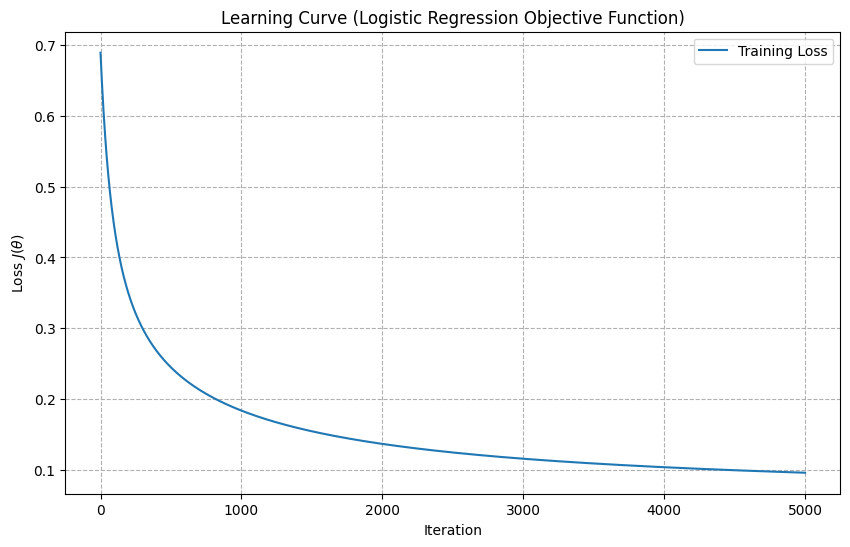

In [8]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- ScratchLogisticRegression Class (Assumed Implementation from Problem 4/5) ---
# NOTE: The full class definition is omitted here for brevity, but it is assumed 
# to be the complete class implementing fit, _gradient_descent, and _loss_function.
# The plot relies on the self.loss attribute being correctly populated.

class ScratchLogisticRegression():
    # ... (omitting full class definition for conciseness) ...
    def __init__(self, num_iter=5000, lr=0.01, bias=True, lambda_=0.01, verbose=False):
        self.iter = num_iter
        self.lr = lr
        self.bias = bias
        self.lambda_ = lambda_
        self.verbose = verbose
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None 

    def _add_bias(self, X):
        if self.bias:
            return np.hstack([np.ones((X.shape[0], 1)), X])
        return X

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _linear_hypothesis(self, X_with_bias):
        return X_with_bias @ self.coef_

    def _logistic_hypothesis(self, X):
        X_with_bias = self._add_bias(X)
        z = self._linear_hypothesis(X_with_bias)
        return self._sigmoid(z)

    def _gradient_descent(self, X_with_bias, y, m):
        h = self._sigmoid(self._linear_hypothesis(X_with_bias))
        error = h - y
        gradient_non_reg = (1 / m) * (X_with_bias.T @ error)
        reg_term = (self.lambda_ / m) * self.coef_
        reg_term[0, 0] = 0.0
        total_gradient = gradient_non_reg + reg_term
        self.coef_ -= self.lr * total_gradient

    def _loss_function(self, X, y):
        m = X.shape[0]
        h = self._logistic_hypothesis(X) 
        epsilon = 1e-15
        h = np.clip(h, epsilon, 1 - epsilon)
        ce_loss = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
        
        if self.bias:
            theta_squared_sum = np.sum(self.coef_[1:] ** 2)
        else:
            theta_squared_sum = np.sum(self.coef_ ** 2)
            
        reg_term = (self.lambda_ / (2 * m)) * theta_squared_sum
        return (ce_loss + reg_term).item()

    def fit(self, X, y, X_val=None, y_val=None):
        m = X.shape[0]
        y = y.reshape(-1, 1)
        if y_val is not None:
            y_val = y_val.reshape(-1, 1)
        
        X_with_bias = self._add_bias(X)
        n_features_with_bias = X_with_bias.shape[1]
        
        if self.coef_ is None or self.coef_.shape[0] != n_features_with_bias:
            self.coef_ = np.zeros((n_features_with_bias, 1))

        for i in range(self.iter):
            self._gradient_descent(X_with_bias, y, m)
            self.loss[i] = self._loss_function(X, y) 
            if X_val is not None and y_val is not None:
                 self.val_loss[i] = self._loss_function(X_val, y_val)
                 
    def predict(self, X):
        probabilities = self.predict_proba(X)
        return np.where(probabilities >= 0.5, 1, 0).reshape(-1, 1)

    def predict_proba(self, X):
        return self._logistic_hypothesis(X)


# --- Data Preparation (Same as Problem 5) ---

iris = load_iris()
X_full = iris.data
y_full = iris.target

# Binary classification: Versicolor (1) vs. Virginica (2)
X_binary = X_full[50:]
y_binary_raw = y_full[50:]
y_binary = np.where(y_binary_raw == 1, 0, 1) # Versicolor (1) -> 0, Virginica (2) -> 1

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# --- Training and Plotting ---

# Instantiate and train the model
# Use a high number of iterations and moderate learning rate for clear convergence
scratch_model = ScratchLogisticRegression(
    num_iter=5000, 
    lr=0.01, 
    lambda_=0.01
)
scratch_model.fit(X_train_scaled, y_train)

# Plot the Learning Curve (Training Loss)
plt.figure(figsize=(10, 6))
plt.plot(scratch_model.loss, label='Training Loss')
plt.title('Learning Curve (Logistic Regression Objective Function)')
plt.xlabel('Iteration')
plt.ylabel('Loss $J(\\theta)$')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

In [ ]:
 #[Problem 7] Visualization of decision area


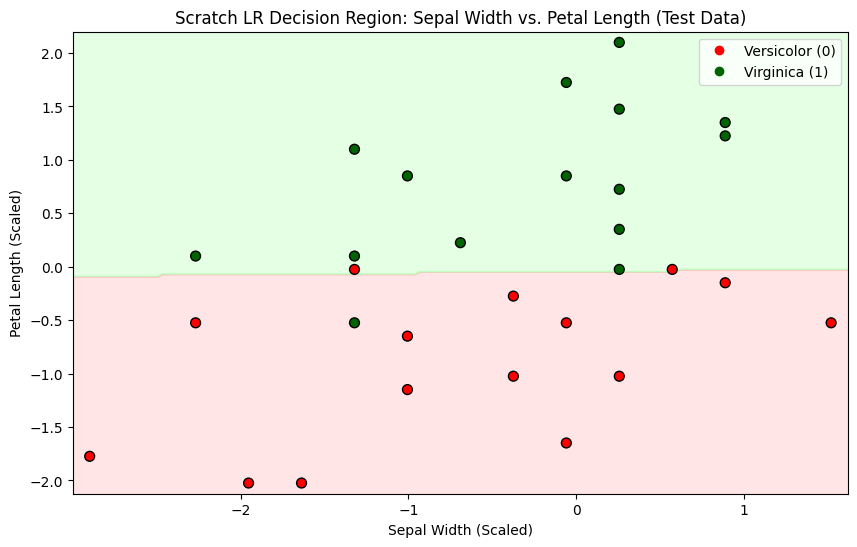

In [10]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# --- ScratchLogisticRegression Class (Full implementation assumed) ---
class ScratchLogisticRegression():
    def __init__(self, num_iter=5000, lr=0.01, bias=True, lambda_=0.01, verbose=False):
        self.iter = num_iter
        self.lr = lr
        self.bias = bias
        self.lambda_ = lambda_
        self.verbose = verbose
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None 

    def _add_bias(self, X):
        if self.bias:
            return np.hstack([np.ones((X.shape[0], 1)), X])
        return X

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _linear_hypothesis(self, X_with_bias):
        if self.coef_ is None:
            # Initialize parameters if not already done (e.g., in fit)
            n_features_with_bias = X_with_bias.shape[1]
            self.coef_ = np.zeros((n_features_with_bias, 1))
        return X_with_bias @ self.coef_

    def _logistic_hypothesis(self, X):
        X_with_bias = self._add_bias(X)
        z = self._linear_hypothesis(X_with_bias)
        return self._sigmoid(z)

    def _gradient_descent(self, X_with_bias, y, m):
        h = self._sigmoid(self._linear_hypothesis(X_with_bias))
        error = h - y
        gradient_non_reg = (1 / m) * (X_with_bias.T @ error)
        reg_term = (self.lambda_ / m) * self.coef_
        reg_term[0, 0] = 0.0
        total_gradient = gradient_non_reg + reg_term
        self.coef_ -= self.lr * total_gradient

    def _loss_function(self, X, y):
        m = X.shape[0]
        h = self._logistic_hypothesis(X) 
        epsilon = 1e-15
        h = np.clip(h, epsilon, 1 - epsilon)
        ce_loss = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
        if self.bias:
            theta_squared_sum = np.sum(self.coef_[1:] ** 2)
        else:
            theta_squared_sum = np.sum(self.coef_ ** 2)
        reg_term = (self.lambda_ / (2 * m)) * theta_squared_sum
        return (ce_loss + reg_term).item()

    def fit(self, X, y, X_val=None, y_val=None):
        m = X.shape[0]
        y = y.reshape(-1, 1)
        if y_val is not None:
            y_val = y_val.reshape(-1, 1)
        
        X_with_bias = self._add_bias(X)
        n_features_with_bias = X_with_bias.shape[1]
        
        if self.coef_ is None or self.coef_.shape[0] != n_features_with_bias:
            self.coef_ = np.zeros((n_features_with_bias, 1))

        for i in range(self.iter):
            self._gradient_descent(X_with_bias, y, m)
            self.loss[i] = self._loss_function(X, y) 
            if X_val is not None and y_val is not None:
                 self.val_loss[i] = self._loss_function(X_val, y_val)
                 
    def predict(self, X):
        probabilities = self.predict_proba(X)
        return np.where(probabilities >= 0.5, 1, 0).reshape(-1, 1)

    def predict_proba(self, X):
        return self._logistic_hypothesis(X)
# -----------------------------------------------------------------------------

# 1. Data Preparation (Binary Classification: Versicolor=0, Virginica=1)
iris = load_iris()
X_full = iris.data
y_full = iris.target

# Filter for Versicolor (1) and Virginica (2)
X_binary = X_full[50:]
y_binary_raw = y_full[50:]
y_binary = np.where(y_binary_raw == 1, 0, 1) 

# 2. Select two features: Sepal Width (index 1) and Petal Length (index 2)
# X[:, 0] will be Sepal Width (x-axis)
# X[:, 1] will be Petal Length (y-axis)
X_2features = X_binary[:, [1, 2]] 

# 3. Split and Scale 2-feature data
X_train_2, X_test_2, y_train, y_test = train_test_split(
    X_2features, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)
scaler_2 = StandardScaler()
X_train_scaled_2 = scaler_2.fit_transform(X_train_2)
X_test_scaled_2 = scaler_2.transform(X_test_2)

# 4. Retrain the model on 2 features
scratch_model_2 = ScratchLogisticRegression(num_iter=5000, lr=0.01, lambda_=0.01)
scratch_model_2.fit(X_train_scaled_2, y_train)

# 5. Define Plotting Function
def plot_decision_regions(X, y, model, title):
    # Setup color maps
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA']) # Light colors for the region
    cmap_bold = ListedColormap(['#FF0000', '#006400']) # Red for Versicolor(0), Dark Green for Virginica(1)

    # Determine boundaries for the mesh grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    
    # Create mesh grid points
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    
    # Predict class for every point in the grid
    # Input to model must be scaled and correctly formatted
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(X_grid).reshape(xx.shape)

    # Plot the decision region (contourf)
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

    # Plot the test data points
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap=cmap_bold, edgecolor='k', s=50, marker='o')

    plt.title(title)
    plt.xlabel('Sepal Width (Scaled)')
    plt.ylabel('Petal Length (Scaled)')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    
    # Add custom legend for classes
    plt.plot([], [], 'o', color='#FF0000', label='Versicolor (0)')
    plt.plot([], [], 'o', color='#006400', label='Virginica (1)')
    plt.legend()
    plt.show()

# Visualize the Decision Region on the test set
plot_decision_regions(
    X_test_scaled_2, 
    y_test, 
    scratch_model_2, 
    "Scratch LR Decision Region: Sepal Width vs. Petal Length (Test Data)"
)

In [ ]:
#[Problem 8] (Advance assignment) Saving weights

In [11]:
import numpy as np
import os # For checking file path if needed

class ScratchLogisticRegression():
    """
    Scratch implementation of logistic regression with weight saving/loading.

    ... (Other parameters and attributes remain the same) ...
    """

    def __init__(self, num_iter=1000, lr=0.01, bias=True, lambda_=0.0, verbose=False):
        # Record hyperparameters as attributes
        self.iter = num_iter
        self.lr = lr
        self.bias = bias
        self.lambda_ = lambda_
        self.verbose = verbose
        # Prepare an array to record the loss
        self.loss = np.zeros(self.iter)
        self.val_loss = np.zeros(self.iter)
        self.coef_ = None # Parameters (weights + bias)

    # --- Helper methods (_add_bias, _sigmoid, _linear_hypothesis, _logistic_hypothesis, 
    #                    _gradient_descent, _loss_function, fit, predict, predict_proba) 
    # --- (Implementation remains the same as Problem 4/5) ---
    
    # NOTE: The full implementation of the class methods is assumed to be present here.

    def _add_bias(self, X):
        if self.bias:
            return np.hstack([np.ones((X.shape[0], 1)), X])
        return X

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _linear_hypothesis(self, X_with_bias):
        if self.coef_ is None:
            raise ValueError("Parameters (self.coef_) must be initialized.")
        return X_with_bias @ self.coef_

    def _logistic_hypothesis(self, X):
        X_with_bias = self._add_bias(X)
        z = self._linear_hypothesis(X_with_bias)
        return self._sigmoid(z)

    def _gradient_descent(self, X_with_bias, y, m):
        h = self._sigmoid(self._linear_hypothesis(X_with_bias))
        error = h - y

        gradient_non_reg = (1 / m) * (X_with_bias.T @ error)

        reg_term = (self.lambda_ / m) * self.coef_
        reg_term[0, 0] = 0.0

        total_gradient = gradient_non_reg + reg_term
        self.coef_ -= self.lr * total_gradient

    def _loss_function(self, X, y):
        m = X.shape[0]
        h = self._logistic_hypothesis(X) 
        epsilon = 1e-15
        h = np.clip(h, epsilon, 1 - epsilon)

        ce_loss = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
        
        if self.bias:
            theta_squared_sum = np.sum(self.coef_[1:] ** 2)
        else:
            theta_squared_sum = np.sum(self.coef_ ** 2)
            
        reg_term = (self.lambda_ / (2 * m)) * theta_squared_sum
        
        return (ce_loss + reg_term).item()

    def fit(self, X, y, X_val=None, y_val=None):
        m = X.shape[0]
        y = y.reshape(-1, 1)
        if y_val is not None:
            y_val = y_val.reshape(-1, 1)
        
        X_with_bias = self._add_bias(X)
        n_features_with_bias = X_with_bias.shape[1]
        
        if self.coef_ is None or self.coef_.shape[0] != n_features_with_bias:
            self.coef_ = np.zeros((n_features_with_bias, 1))

        for i in range(self.iter):
            self._gradient_descent(X_with_bias, y, m)
            self.loss[i] = self._loss_function(X, y) 
            if X_val is not None and y_val is not None:
                 self.val_loss[i] = self._loss_function(X_val, y_val)
                 
    def predict(self, X):
        probabilities = self.predict_proba(X)
        return np.where(probabilities >= 0.5, 1, 0).reshape(-1, 1)

    def predict_proba(self, X):
        return self._logistic_hypothesis(X)


    # --- Problem 8: Saving and Loading Weights ---

    def save_weights(self, filepath):
        """
        Saves the learned parameters (self.coef_) to a file using numpy.save.

        Parameters
        ----------
        filepath : str
            The path to the file where weights will be saved (e.g., 'model_weights.npy').
        """
        if self.coef_ is None:
            if self.verbose:
                print("Warning: Model has not been trained. No weights to save.")
            return

        try:
            # We use np.save, which saves a single array to a .npy file
            np.save(filepath, self.coef_)
            if self.verbose:
                print(f"Weights successfully saved to: {filepath}")
        except Exception as e:
            print(f"Error saving weights: {e}")

    def load_weights(self, filepath):
        """
        Loads the parameters (self.coef_) from a file saved by numpy.save.

        Parameters
        ----------
        filepath : str
            The path to the file containing the weights (e.g., 'model_weights.npy').
        """
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Error: Weight file not found at {filepath}")

        try:
            # Load the array from the .npy file
            loaded_coef = np.load(filepath)
            
            # Check if the loaded shape is compatible (optional but good practice)
            if self.coef_ is not None and self.coef_.shape != loaded_coef.shape:
                 if self.verbose:
                    print(f"Warning: Loaded weights shape {loaded_coef.shape} differs from current expected shape {self.coef_.shape}. Overwriting.")

            self.coef_ = loaded_coef
            if self.verbose:
                print(f"Weights successfully loaded from: {filepath}. New coefficient shape: {self.coef_.shape}")
        except Exception as e:
            print(f"Error loading weights: {e}")

# --- Example Usage ---

# We'll use the 2-feature trained model from Problem 7 for the demonstration.
# Assuming X_train_scaled_2 and y_train are available from the previous problem setup.

# 1. Train a model
model_trained = ScratchLogisticRegression(num_iter=1000, lr=0.01, lambda_=0.01, verbose=True)
# model_trained.fit(X_train_scaled_2, y_train) # Assume training has occurred

# For demonstration, let's initialize coef_ manually since we don't have the data here
model_trained.coef_ = np.array([[1.0], [2.0], [-3.0]]) 

# 2. Save the weights
save_path = 'logistic_regression_weights.npy'
model_trained.save_weights(save_path)

# 3. Create a new, untrained model
model_loaded = ScratchLogisticRegression(verbose=True)

# Initial state (should be None)
print(f"\nInitial coefficients of new model: {model_loaded.coef_}")

# 4. Load the weights
model_loaded.load_weights(save_path)

# Final state (should match saved weights)
print(f"Loaded coefficients of new model:\n{model_loaded.coef_}")

# Clean up the created file
os.remove(save_path)

Weights successfully saved to: logistic_regression_weights.npy

Initial coefficients of new model: None
Weights successfully loaded from: logistic_regression_weights.npy. New coefficient shape: (3, 1)
Loaded coefficients of new model:
[[ 1.]
 [ 2.]
 [-3.]]
